# Clinical Feature Analysis - QSVM Phase 1
**Task A - Prakshi**

Extract clinical features (CDR, MMSE, ASF, EDUC, SES), scale, reduce to 2 PCA components, and save for multimodal QSVM training.

In [1]:
# Cell 1 - Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")
print("All imports successful")

All imports successful


In [2]:
# Cell 2 - Shared Dataset Loading Block
import pandas as pd
import numpy as np

df = pd.read_csv("data/multimodal_dementia_dataset.csv")

assert df.shape == (225, 29), f"Unexpected shape: {df.shape}"
assert df.isnull().sum().sum() == 0, "NaNs found in dataset!"
assert df["Label"].isin([0, 1]).all(), "Invalid labels found!"

print(f"Dataset loaded: {df.shape}")
print("Label distribution:")
print(df["Label"].value_counts())
print(f"Columns: {df.columns.tolist()}")

Dataset loaded: (225, 29)
Label distribution:
Label
0    124
1    101
Name: count, dtype: int64
Columns: ['Subject_ID', 'CDR', 'MMSE', 'ASF', 'EDUC', 'SES', 'nWBV', 'eTIV', 'hippocampal_volume', 'cortical_thickness', 'pause_rate', 'speech_rate', 'pitch_mean', 'jitter', 'shimmer', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'Label']


In [3]:
# Cell 3 - Explore Clinical Features
CLINICAL_FEATURES = ["CDR", "MMSE", "ASF", "EDUC", "SES"]

print("=== CLINICAL FEATURE OVERVIEW ===")
print(df[CLINICAL_FEATURES].describe().round(3))
print("Null values:", df[CLINICAL_FEATURES].isnull().sum().to_dict())
print()
print("=== PER-CLASS MEANS ===")
print(df.groupby("Label")[CLINICAL_FEATURES].mean().round(3))

=== CLINICAL FEATURE OVERVIEW ===
           CDR     MMSE      ASF     EDUC      SES
count  225.000  225.000  225.000  225.000  225.000
mean     0.549   23.564    1.123   13.289    2.698
std      0.625    4.945    0.148    2.605    1.133
min      0.000   12.000    0.800    6.000    1.000
25%      0.000   19.000    1.020   12.000    2.000
50%      0.500   26.000    1.124   13.000    3.000
75%      1.000   28.000    1.218   15.000    3.000
max      2.000   30.000    1.517   21.000    5.000
Null values: {'CDR': 0, 'MMSE': 0, 'ASF': 0, 'EDUC': 0, 'SES': 0}

=== PER-CLASS MEANS ===
         CDR    MMSE    ASF    EDUC    SES
Label                                     
0      0.181  27.597  1.193  13.976  2.581
1      1.000  18.614  1.036  12.446  2.842


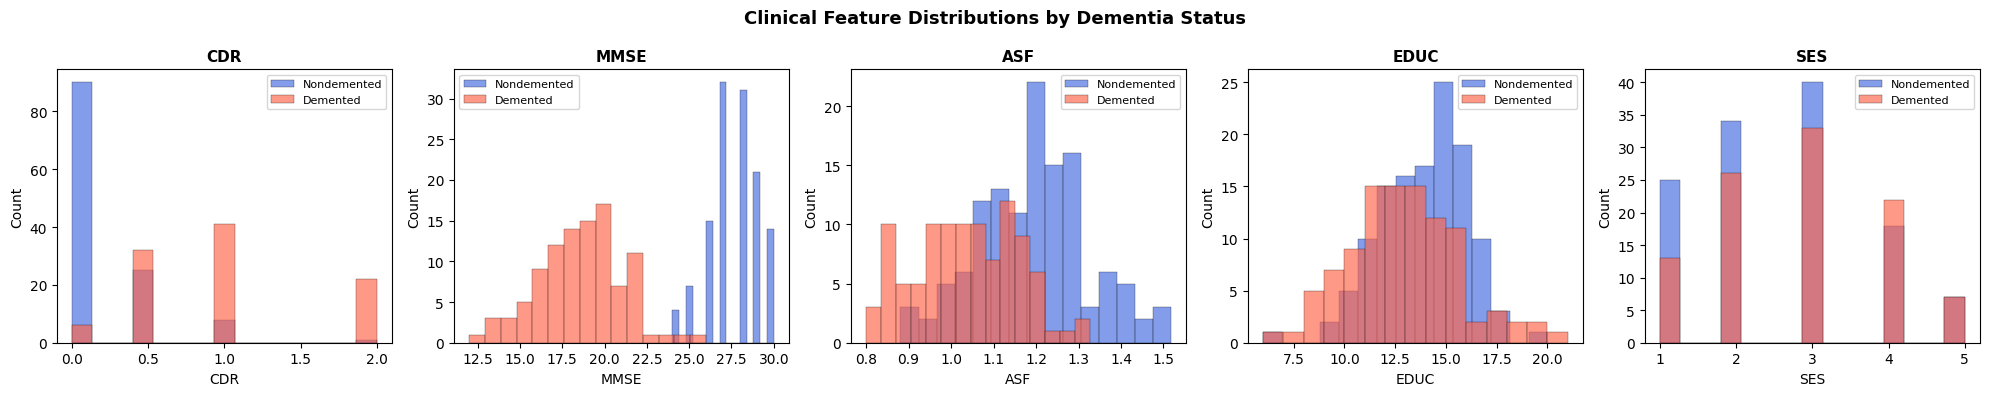

Saved: results/plots/clinical_feature_distributions.png


In [4]:
# Cell 4 - Feature Distribution Plots
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
colors = {0: "royalblue", 1: "tomato"}
label_names = {0: "Nondemented", 1: "Demented"}

for ax, feat in zip(axes, CLINICAL_FEATURES):
    for lbl in [0, 1]:
        ax.hist(df[df["Label"]==lbl][feat],
                bins=15, alpha=0.65, color=colors[lbl],
                label=label_names[lbl], edgecolor="black", linewidth=0.3)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Clinical Feature Distributions by Dementia Status",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/plots/clinical_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/plots/clinical_feature_distributions.png")

In [5]:
# Cell 5 - Select Features + Scale
X_clinical = df[CLINICAL_FEATURES].values
y = df["Label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clinical)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Mean after scaling (should be ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"Std  after scaling (should be ~1): {X_scaled.std(axis=0).round(4)}")

Feature matrix shape: (225, 5)
Mean after scaling (should be ~0): [ 0.  0. -0. -0.  0.]
Std  after scaling (should be ~1): [1. 1. 1. 1. 1.]


Explained variance per component: [0.4208 0.2177]
Total variance retained: 63.84%
Shape after PCA: (225, 2)


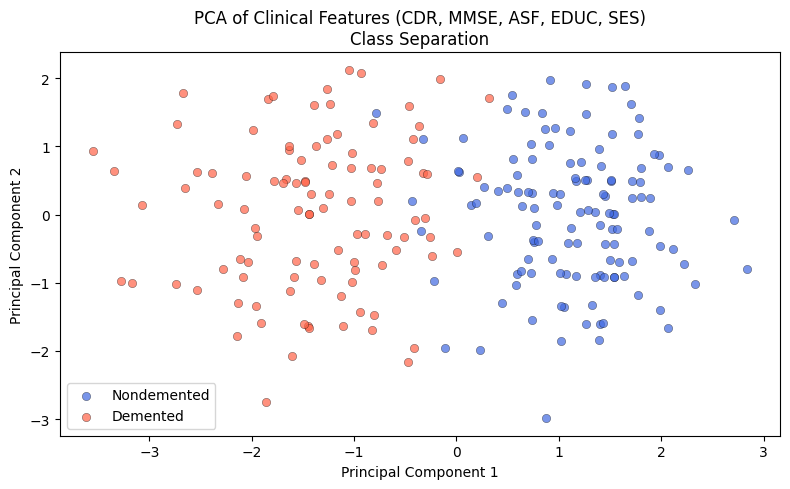

Saved: results/plots/clinical_pca.png


In [6]:
# Cell 6 - PCA Reduction to 2 Components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance per component: {pca.explained_variance_ratio_.round(4)}")
print(f"Total variance retained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Shape after PCA: {X_pca.shape}")

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[y==0, 0], X_pca[y==0, 1],
            c="royalblue", label="Nondemented", alpha=0.7, edgecolors="k", linewidths=0.3)
plt.scatter(X_pca[y==1, 0], X_pca[y==1, 1],
            c="tomato", label="Demented", alpha=0.7, edgecolors="k", linewidths=0.3)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Clinical Features (CDR, MMSE, ASF, EDUC, SES)" + chr(10) + "Class Separation")
plt.legend()
plt.tight_layout()
plt.savefig("results/plots/clinical_pca.png", dpi=150)
plt.show()
print("Saved: results/plots/clinical_pca.png")

In [7]:
# Cell 7 - Save PCA Features + Labels
np.save("results/X_clinical_pca.npy", X_pca)
np.save("results/y_labels.npy", y)

print(f"Saved: results/X_clinical_pca.npy  - shape: {X_pca.shape}")
print(f"Saved: results/y_labels.npy         - shape: {y.shape}")

check_X = np.load("results/X_clinical_pca.npy")
check_y = np.load("results/y_labels.npy")
assert check_X.shape == (225, 2), f"Wrong shape: {check_X.shape}"
assert check_y.shape == (225,),   f"Wrong shape: {check_y.shape}"
print("Reload check passed")
print(f"   X_clinical_pca: {check_X.shape}  |  y_labels: {check_y.shape}")

Saved: results/X_clinical_pca.npy  - shape: (225, 2)
Saved: results/y_labels.npy         - shape: (225,)
Reload check passed
   X_clinical_pca: (225, 2)  |  y_labels: (225,)
